**We would like to acknowledge Stanford University's CS231n on which we based the development of this project.**

In [16]:
import os
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath('gan.py')))
print('cwd:', os.getcwd())

cwd: /Users/kevinalvarez/SCHOOL/CS_C147B/project1/project1/GAN


## Enabling GPU
To enable GPU on your gcloud instance, make sure you selected a GPU machine type when creating your VM. You can verify the GPU is available by running `nvidia-smi` in the terminal.

# Generative Adversarial Networks (GANs)

In C147/C247, all the applications of neural networks that we have explored have been **discriminative models** that take an input and are trained to produce a labeled output. In this notebook, we will expand our repetoire, and build **generative models** using neural networks. Specifically, we will learn how to build models which generate novel images that resemble a set of training images.

### What is a GAN?

In 2014, [Goodfellow et al.](https://arxiv.org/abs/1406.2661) presented a method for training generative models called Generative Adversarial Networks (GANs for short). In a GAN, we build two different neural networks. Our first network is a traditional classification network, called the **discriminator**. We will train the discriminator to take images and classify them as being real (belonging to the training set) or fake (not present in the training set). Our other network, called the **generator**, will take random noise as input and transform it using a neural network to produce images. The goal of the generator is to fool the discriminator into thinking the images it produced are real.

We can think of this back and forth process of the generator ($G$) trying to fool the discriminator ($D$) and the discriminator trying to correctly classify real vs. fake as a minimax game:
$$\underset{G}{\text{minimize}}\; \underset{D}{\text{maximize}}\; \mathbb{E}_{x \sim p_\text{data}}\left[\log D(x)\right] + \mathbb{E}_{z \sim p(z)}\left[\log \left(1-D(G(z))\right)\right]$$
where $z \sim p(z)$ are the random noise samples, $G(z)$ are the generated images using the neural network generator $G$, and $D$ is the output of the discriminator, specifying the probability of an input being real. In [Goodfellow et al.](https://arxiv.org/abs/1406.2661), they analyze this minimax game and show how it relates to minimizing the Jensen-Shannon divergence between the training data distribution and the generated samples from $G$.

To optimize this minimax game, we will alternate between taking gradient *descent* steps on the objective for $G$ and gradient *ascent* steps on the objective for $D$:
1. update the **generator** ($G$) to minimize the probability of the __discriminator making the correct choice__.
2. update the **discriminator** ($D$) to maximize the probability of the __discriminator making the correct choice__.

While these updates are useful for analysis, they do not perform well in practice. Instead, we will use a different objective when we update the generator: maximize the probability of the **discriminator making the incorrect choice**. This small change helps to allevaiate problems with the generator gradient vanishing when the discriminator is confident. This is the standard update used in most GAN papers and was used in the original paper from [Goodfellow et al.](https://arxiv.org/abs/1406.2661).

In this assignment, we will alternate the following updates:
1. Update the generator ($G$) to maximize the probability of the discriminator making the incorrect choice on generated data:
$$\underset{G}{\text{maximize}}\;  \mathbb{E}_{z \sim p(z)}\left[\log D(G(z))\right]$$
2. Update the discriminator ($D$), to maximize the probability of the discriminator making the correct choice on real and generated data:
$$\underset{D}{\text{maximize}}\; \mathbb{E}_{x \sim p_\text{data}}\left[\log D(x)\right] + \mathbb{E}_{z \sim p(z)}\left[\log \left(1-D(G(z))\right)\right]$$

Here's an example of what your outputs from the 3 different models you're going to train should look like. Note that GANs are sometimes finicky, so your outputs might not look exactly like this. This is just meant to be a *rough* guideline of the kind of quality you can expect:


## Assignment Overview

All your code goes in `gan.py`. The notebook imports from it and runs checks — do not modify the notebook cells.

| Task | Points |
|---|---|
| `Discriminator` — MLP architecture | 1 |
| `Generator` — MLP architecture | 1 |
| `discriminator_loss` + `generator_loss` — BCE GAN loss | 2 |
| `ls_discriminator_loss` + `ls_generator_loss` — LSGAN loss | 2 |
| `DCDiscriminator` — convolutional architecture | 1 |
| `DCGenerator` — convolutional architecture | 1 |
| Inline Questions 4, 5, 6 | 3 |
| **Total** | **11** |

`sample_noise`, `get_optimizer`, `bce_loss`, and `run_a_gan` are already implemented for you.


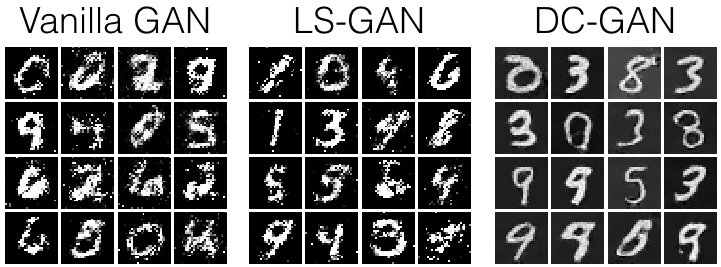

In [17]:
# Run this cell to see sample outputs.
from IPython.display import Image
Image('assets/gan_outputs.png')

In [18]:

# Setup cell.
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as dset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from gan import rel_error, count_params

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

def show_images(images):
    images = np.reshape(images, [images.shape[0], -1])
    sqrtn = int(np.ceil(np.sqrt(images.shape[0])))
    sqrtimg = int(np.ceil(np.sqrt(images.shape[1])))

    fig = plt.figure(figsize=(sqrtn, sqrtn))
    gs = gridspec.GridSpec(sqrtn, sqrtn)
    gs.update(wspace=0.05, hspace=0.05)

    for i, img in enumerate(images):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(img.reshape([sqrtimg, sqrtimg]))
    return

answers = dict(np.load('assets/gan-checks.npz'))
device = torch.device('cuda') if torch.cuda.is_available() else (torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu'))
print(device)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
mps


## Dataset
GANs are notoriously finicky with hyperparameters, and also require many training epochs. In order to make this assignment approachable, we will be working on the MNIST dataset, which is 60,000 training and 10,000 test images. Each picture contains a centered image of white digit on black background (0 through 9). This was one of the first datasets used to train convolutional neural networks and it is fairly easy -- a standard CNN model can easily exceed 99% accuracy.

To simplify our code here, we will use the PyTorch MNIST wrapper, which downloads and loads the MNIST dataset. See the [documentation](https://github.com/pytorch/vision/blob/master/torchvision/datasets/mnist.py) for more information about the interface. The data will be saved into a folder called `MNIST`.

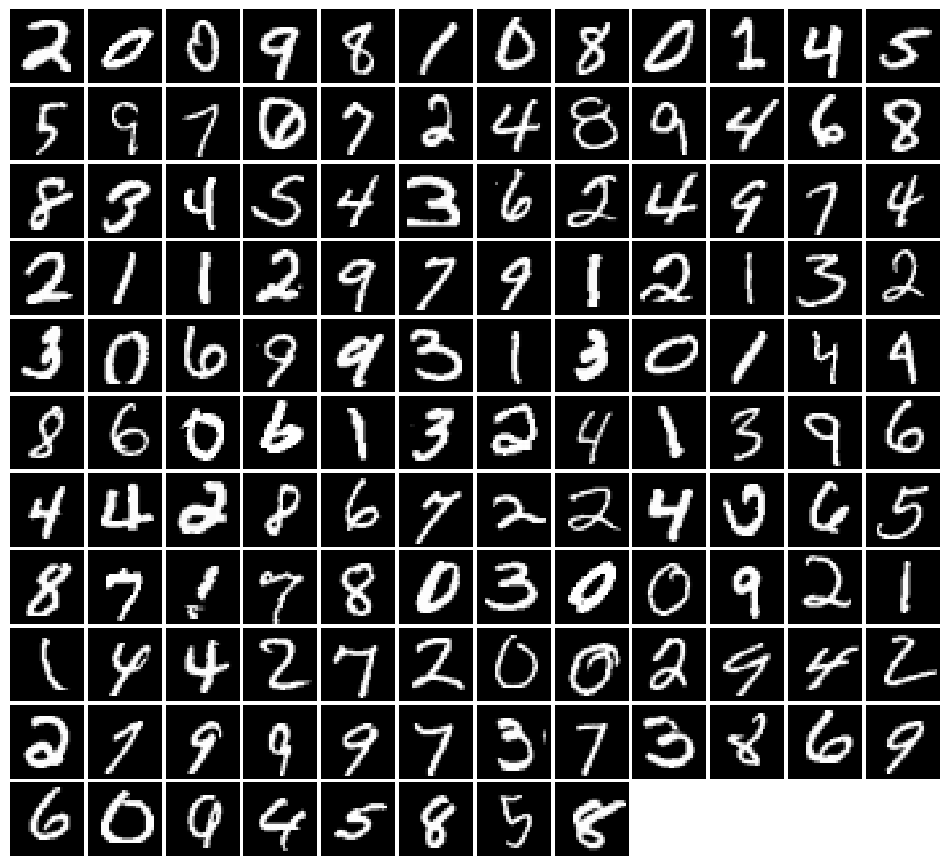

In [19]:
NOISE_DIM = 96
batch_size = 128

mnist_train = dset.MNIST('./mnist_data', train=True, download=True, transform=T.ToTensor())
loader_train = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)

iterator = iter(loader_train)
imgs, labels = next(iterator)
imgs = imgs.view(batch_size, 784).numpy().squeeze()
show_images(imgs)

## PyTorch Utilities

For the convolutional generator you will need to reshape tensors between flat vectors and image tensors. Use PyTorch's built-in `nn.Flatten()` and `nn.Unflatten(dim, shape)` — no need to import anything extra.

We also provide a weight initializer (and call it for you) that uses Xavier initialization instead of PyTorch's uniform default.

In [20]:
from gan import initialize_weights

# Discriminator (1 point)
Our first step is to build a discriminator. Fill in `self.model` as an `nn.Sequential` inside the `Discriminator` class in `gan.py`. All fully connected layers should include bias terms. The architecture is:
 * Fully connected layer with input size 784 and output size 256
 * LeakyReLU with alpha 0.01
 * Fully connected layer with input_size 256 and output size 256
 * LeakyReLU with alpha 0.01
 * Fully connected layer with input size 256 and output size 1

Recall that the Leaky ReLU nonlinearity computes $f(x) = \max(\alpha x, x)$ for some fixed constant $\alpha$; for the LeakyReLU nonlinearities in the architecture above we set $\alpha=0.01$.

The output of the discriminator should have shape `[batch_size, 1]`, and contain real numbers corresponding to the scores that each of the `batch_size` inputs is a real image.

Implement `Discriminator` in `gan.py`

Test to make sure the number of parameters in the discriminator is correct:

In [21]:
from gan import Discriminator

def test_discriminator(true_count=267009):
    model = Discriminator()
    cur_count = count_params(model)
    if cur_count != true_count:
        print('Incorrect number of parameters in discriminator. Check your architecture.')
    else:
        print('Correct number of parameters in discriminator.')

test_discriminator()

Correct number of parameters in discriminator.


# Generator (1 point)
Now to build the generator network. Fill in `self.model` as an `nn.Sequential` inside the `Generator` class in `gan.py`:
 * Fully connected layer from noise_dim to 1024
 * `ReLU`
 * Fully connected layer with size 1024
 * `ReLU`
 * Fully connected layer with size 784
 * `TanH` (to clip the image to be in the range of [-1,1])

All fully connected layers should include bias terms. Implement `Generator` in `gan.py`

Test to make sure the number of parameters in the generator is correct:

In [22]:
from gan import Generator

def test_generator(true_count=1858320):
    model = Generator(noise_dim=4)
    cur_count = count_params(model)
    if cur_count != true_count:
        print('Incorrect number of parameters in generator. Check your architecture.')
    else:
        print('Correct number of parameters in generator.')

test_generator()

Correct number of parameters in generator.


# GAN Loss (2 points)

Compute the generator and discriminator loss. The generator loss is:
$$\ell_G  =  -\mathbb{E}_{z \sim p(z)}\left[\log D(G(z))\right]$$
and the discriminator loss is:
$$ \ell_D = -\mathbb{E}_{x \sim p_\text{data}}\left[\log D(x)\right] - \mathbb{E}_{z \sim p(z)}\left[\log \left(1-D(G(z))\right)\right]$$
Note that these are negated from the equations presented earlier as we will be *minimizing* these losses.

**HINTS**: You should use the `bce_loss` function defined below to compute the binary cross entropy loss which is needed to compute the log probability of the true label given the logits output from the discriminator. Given a score $s\in\mathbb{R}$ and a label $y\in\{0, 1\}$, the binary cross entropy loss is

$$ bce(s, y) = -y * \log(s) - (1 - y) * \log(1 - s) $$

A naive implementation of this formula can be numerically unstable, so we have provided a numerically stable implementation that relies on PyTorch's `nn.BCEWithLogitsLoss`.

You will also need to compute labels corresponding to real or fake and use the logit arguments to determine their size. Make sure you use the `torch.float32` data type (same as `torch.float`) for compatibility with BCEWithLogitsLoss, which uses floating point data types, and move tensors to GPU (if applicable) using `u = u.to(device)`.

`true_labels = torch.ones(size, dtype=torch.float32).to(device)`

or

`true_labels = torch.ones(size, device=device) # uses torch.float32 by default`

Instead of computing the expectation of $\log D(G(z))$, $\log D(x)$ and $\log \left(1-D(G(z))\right)$, we will be averaging over elements of the minibatch. This is taken care of in `bce_loss` which combines the loss by averaging. **Hint**: Do NOT concatenate real and fake losses. Sum the two (empirical) expectations instead.

Implement `discriminator_loss` and `generator_loss` in `gan.py`

Test your generator and discriminator loss. You should see errors < 1e-7.

In [23]:
from gan import bce_loss, discriminator_loss, generator_loss

def test_discriminator_loss(logits_real, logits_fake, d_loss_true):
    d_loss = discriminator_loss(
        torch.tensor(logits_real, dtype=torch.float32).to(device),
        torch.tensor(logits_fake, dtype=torch.float32).to(device)
    ).cpu().numpy()
    print(f'Maximum error in d_loss: {rel_error(d_loss_true, d_loss):g}')

test_discriminator_loss(
    answers['logits_real'],
    answers['logits_fake'],
    answers['d_loss_true']
)

Maximum error in d_loss: 3.97058e-09


In [24]:
def test_generator_loss(logits_fake, g_loss_true):
    g_loss = generator_loss(
        torch.tensor(logits_fake, dtype=torch.float32).to(device)
    ).cpu().numpy()
    print(f'Maximum error in g_loss: {rel_error(g_loss_true, g_loss):g}')

test_generator_loss(
    answers['logits_fake'],
    answers['g_loss_true']
)

Maximum error in g_loss: 4.4518e-09


# Training a GAN!

We provide you the main training loop. You won't need to change `run_a_gan` in `gan.py`, but we encourage you to read through it for your own understanding. Training takes about 7 minutes on CPU and about 1-2 minutes on GPU.

If it doesn't work the first time, check the discriminator: Did you use `nn.Flatten()`?

In [25]:
from gan import get_optimizer, run_a_gan

D = Discriminator().to(device)
G = Generator().to(device)

D_solver = get_optimizer(D)
G_solver = get_optimizer(G)

images = run_a_gan(
    D,
    G,
    D_solver,
    G_solver,
    discriminator_loss,
    generator_loss,
    loader_train
)

Iter: 0, D: 1.3868, G: 0.6702
Iter: 250, D: 1.9030, G: 1.7000
Iter: 500, D: 1.3504, G: 2.6499
Iter: 750, D: 1.1718, G: 1.0185
Iter: 1000, D: 1.2443, G: 0.9599
Iter: 1250, D: 1.2445, G: 1.0783
Iter: 1500, D: 1.4327, G: 0.6930
Iter: 1750, D: 1.2622, G: 0.8660
Iter: 2000, D: 1.3404, G: 0.7836
Iter: 2250, D: 1.2304, G: 0.8490
Iter: 2500, D: 1.2838, G: 0.9378
Iter: 2750, D: 1.4204, G: 0.8694
Iter: 3000, D: 1.3006, G: 0.8073
Iter: 3250, D: 1.2476, G: 0.8205
Iter: 3500, D: 1.3294, G: 0.9608
Iter: 3750, D: 1.2554, G: 1.2709
Iter: 4000, D: 1.2776, G: 0.9077
Iter: 4250, D: 1.3418, G: 0.7402
Iter: 4500, D: 1.2774, G: 0.7744


Run the cell below to show the generated images.

Iter: 0


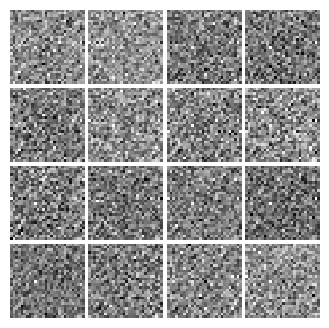


Iter: 250


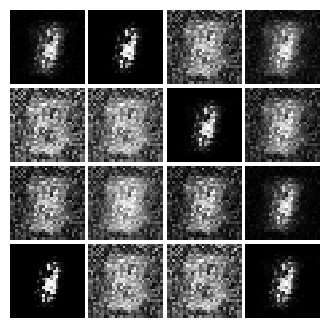


Iter: 500


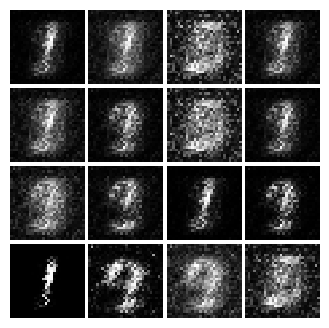


Iter: 750


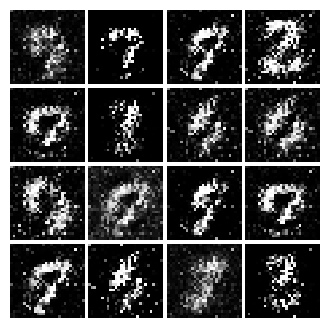


Iter: 1000


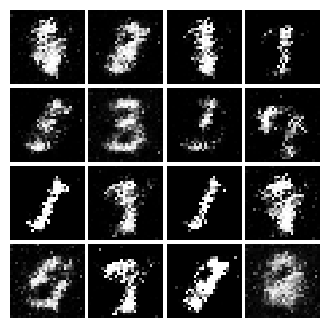


Iter: 1250


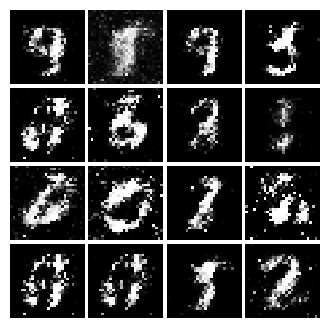


Iter: 1500


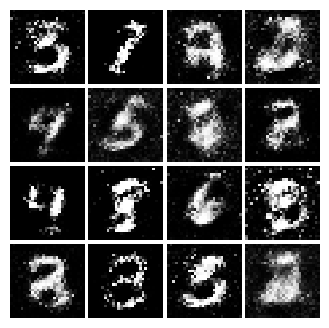


Iter: 1750


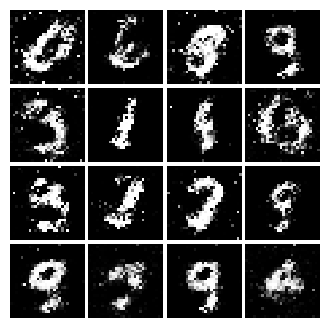


Iter: 2000


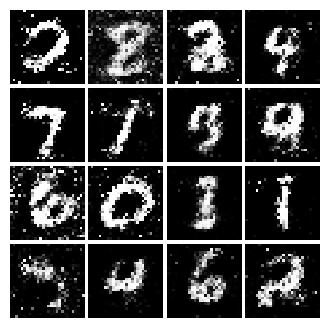


Iter: 2250


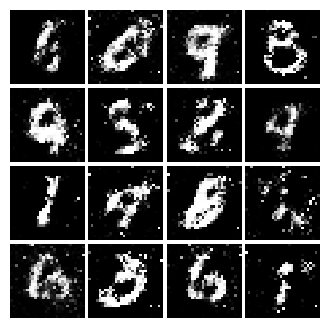


Iter: 2500


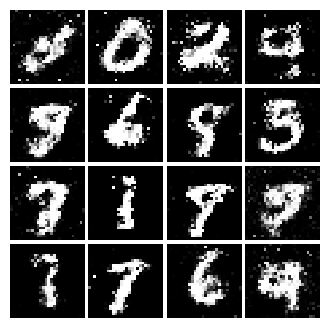


Iter: 2750


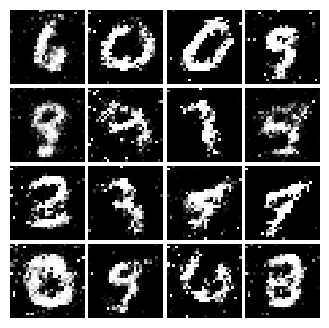


Iter: 3000


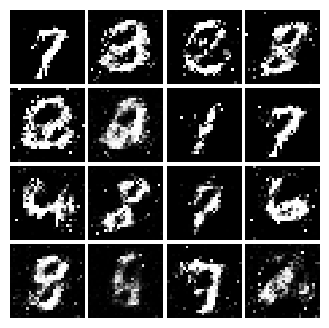


Iter: 3250


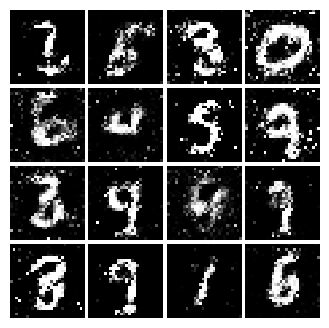


Iter: 3500


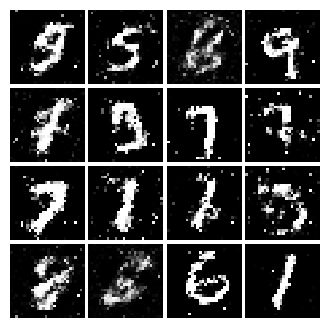


Iter: 3750


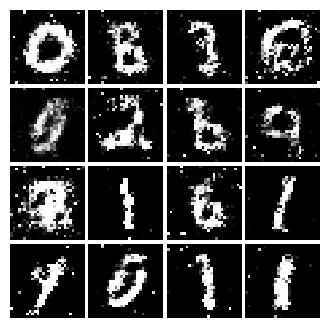


Iter: 4000


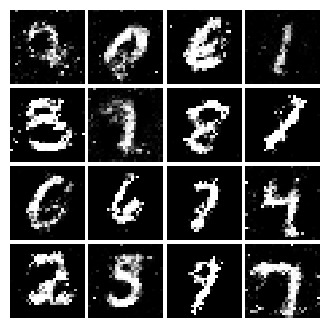


Iter: 4250


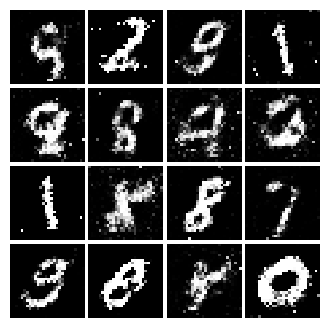


Iter: 4500


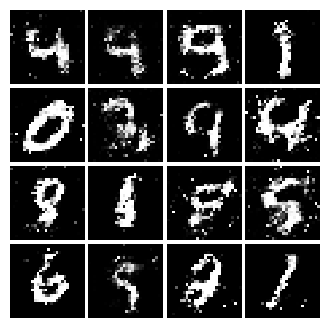

In [26]:
numIter = 0
for img in images:
    print(f'Iter: {numIter}')
    show_images(img)
    plt.show()
    numIter += 250
    print()

## Inline Question 1

What does your final vanilla GAN image look like?

Vanilla GAN final image:


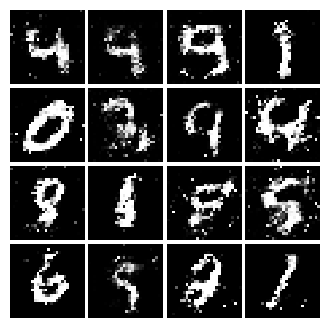

In [27]:
# This output is your answer.
print('Vanilla GAN final image:')
show_images(images[-1])
plt.show()

Well that wasn't so hard, was it? In the iterations in the low 100s you should see black backgrounds, fuzzy shapes as you approach iteration 1000, and decent shapes, about half of which will be sharp and clearly recognizable as we pass 3000.

# Least Squares GAN (2 points)
We'll now look at [Least Squares GAN](https://arxiv.org/abs/1611.04076), a newer, more stable alernative to the original GAN loss function. For this part, all we have to do is change the loss function and retrain the model. We'll implement equation (9) in the paper, with the generator loss:
$$\ell_G  =  \frac{1}{2}\mathbb{E}_{z \sim p(z)}\left[\left(D(G(z))-1\right)^2\right]$$
and the discriminator loss:
$$ \ell_D = \frac{1}{2}\mathbb{E}_{x \sim p_\text{data}}\left[\left(D(x)-1\right)^2\right] + \frac{1}{2}\mathbb{E}_{z \sim p(z)}\left[ \left(D(G(z))\right)^2\right]$$


**HINTS**: Instead of computing the expectation, we will be averaging over elements of the minibatch, so make sure to combine the loss by averaging instead of summing. When plugging in for $D(x)$ and $D(G(z))$ use the direct output from the discriminator (`scores_real` and `scores_fake`). **If** you get errors of 0.333..., you probably forgot to include the 1/2 term.

Implement `ls_discriminator_loss`, `ls_generator_loss` in `gan.py`

Before running a GAN with our new loss function, let's check it:

In [28]:
from gan import ls_discriminator_loss, ls_generator_loss

def test_lsgan_loss(score_real, score_fake, d_loss_true, g_loss_true):
    score_real = torch.tensor(score_real, dtype=torch.float32).to(device)
    score_fake = torch.tensor(score_fake, dtype=torch.float32).to(device)
    d_loss = ls_discriminator_loss(score_real, score_fake).cpu().numpy()
    g_loss = ls_generator_loss(score_fake).cpu().numpy()
    print(f'Maximum error in d_loss: {rel_error(d_loss_true, d_loss):g}')
    print(f'Maximum error in g_loss: {rel_error(g_loss_true, g_loss):g}')

test_lsgan_loss(
    answers['logits_real'],
    answers['logits_fake'],
    answers['d_loss_lsgan_true'],
    answers['g_loss_lsgan_true']
)

Maximum error in d_loss: 1.53171e-08
Maximum error in g_loss: 2.7837e-09


Run the following cell to train your model! Training takes about 7 minutes on CPU and about 1-2 minutes on GPU.

In [29]:
D_LS = Discriminator().to(device)
G_LS = Generator().to(device)

D_LS_solver = get_optimizer(D_LS)
G_LS_solver = get_optimizer(G_LS)

images = run_a_gan(
    D_LS,
    G_LS,
    D_LS_solver,
    G_LS_solver,
    ls_discriminator_loss,
    ls_generator_loss,
    loader_train
)

Iter: 0, D: 0.5023, G: 0.4654
Iter: 250, D: 0.2514, G: 0.2195
Iter: 500, D: 0.1600, G: 0.3848
Iter: 750, D: 0.0922, G: 0.5187
Iter: 1000, D: 0.1888, G: 0.6291
Iter: 1250, D: 0.1988, G: 0.2616
Iter: 1500, D: 0.2404, G: 0.1592
Iter: 1750, D: 0.2464, G: 0.1585
Iter: 2000, D: 0.2198, G: 0.1595
Iter: 2250, D: 0.2370, G: 0.2005
Iter: 2500, D: 0.2302, G: 0.1624
Iter: 2750, D: 0.2247, G: 0.1642
Iter: 3000, D: 0.2308, G: 0.1379
Iter: 3250, D: 0.2274, G: 0.1598
Iter: 3500, D: 0.2236, G: 0.1352
Iter: 3750, D: 0.2330, G: 0.1408
Iter: 4000, D: 0.2296, G: 0.1643
Iter: 4250, D: 0.2405, G: 0.1572
Iter: 4500, D: 0.2389, G: 0.1607


Run the cell below to show generated images.

Iter: 0


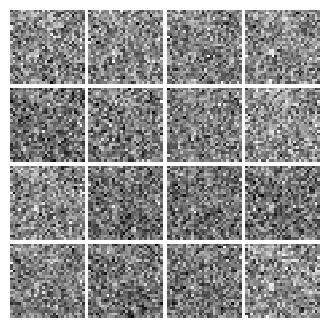


Iter: 250


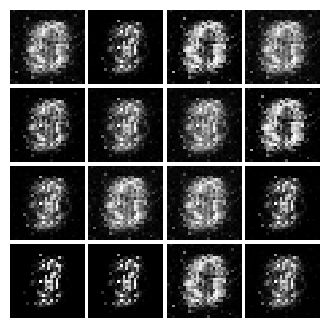


Iter: 500


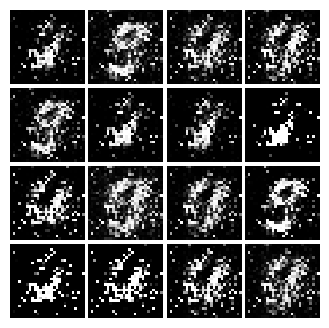


Iter: 750


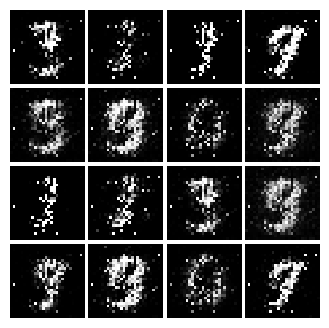


Iter: 1000


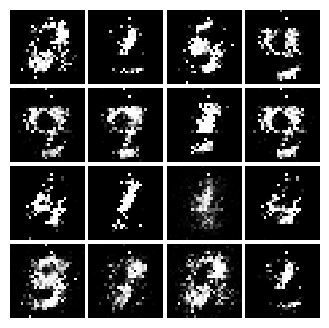


Iter: 1250


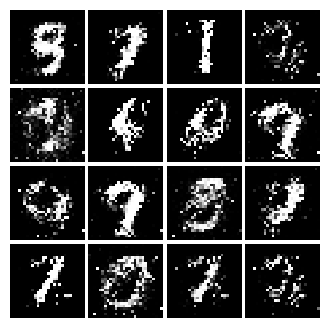


Iter: 1500


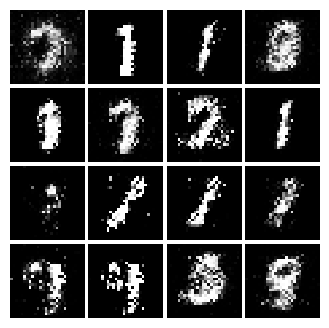


Iter: 1750


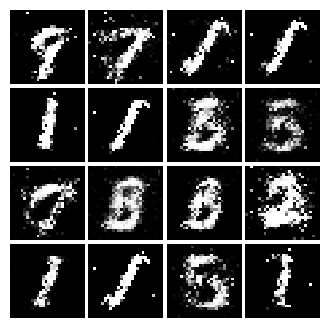


Iter: 2000


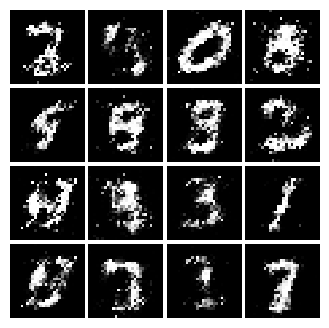


Iter: 2250


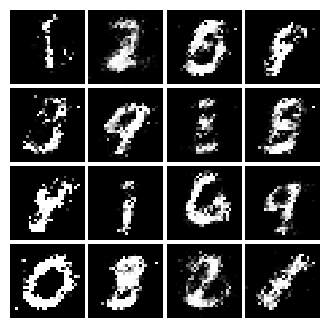


Iter: 2500


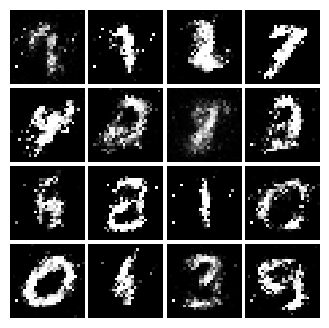


Iter: 2750


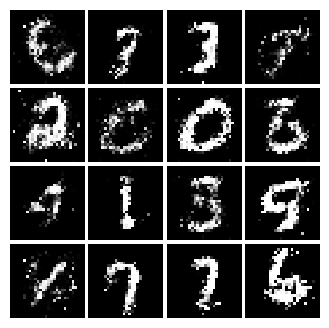


Iter: 3000


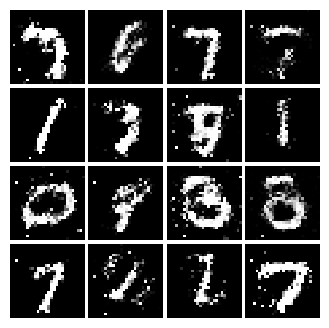


Iter: 3250


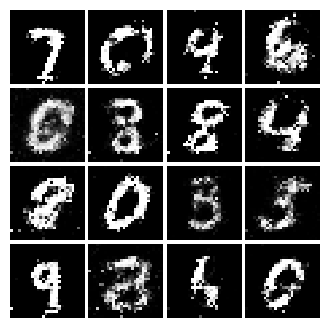


Iter: 3500


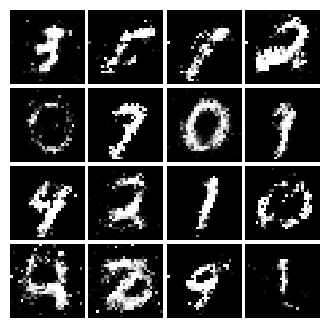


Iter: 3750


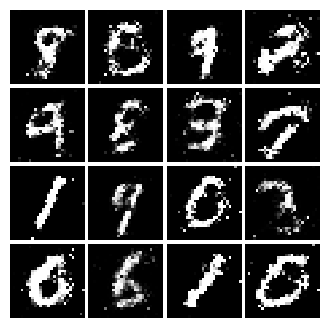


Iter: 4000


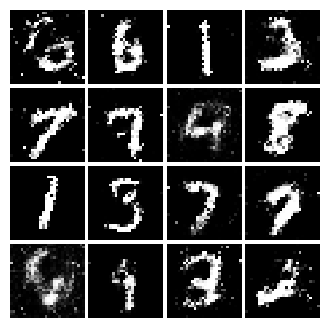


Iter: 4250


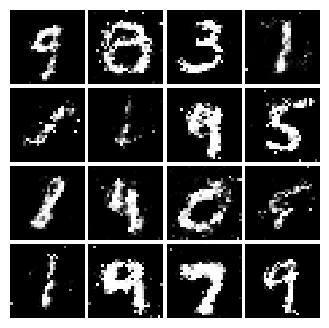


Iter: 4500


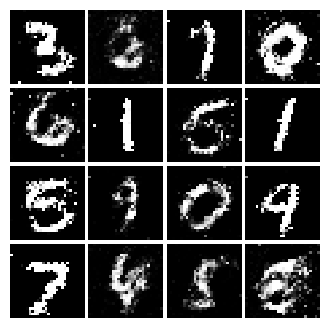

In [30]:
numIter = 0
for img in images:
    print(f'Iter: {numIter}')
    show_images(img)
    plt.show()
    numIter += 250
    print()

## Inline Question 2

What does your final LSGAN image look like?

LSGAN final image:


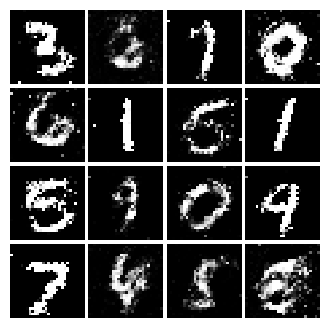

In [31]:
# This output is your answer.
print('LSGAN final image:')
show_images(images[-1])
plt.show()

# Deep Convolutional GAN (2 points)
In the first part of the notebook, we implemented an almost direct copy of the original GAN network from Ian Goodfellow. However, this network architecture allows no real spatial reasoning. It is unable to reason about things like "sharp edges" in general because it lacks any convolutional layers. Thus, in this section, we will implement some of the ideas from [DCGAN](https://arxiv.org/abs/1511.06434), where we use convolutional networks

#### Discriminator
We will use a discriminator inspired by the TensorFlow MNIST classification tutorial, which is able to get above 99% accuracy on the MNIST dataset fairly quickly. **Hint**: There is no need to specify padding. **Warning**: If you use LazyLinear I will take off points.
* Conv2D: 32 Filters, 5x5, Stride 1
* Leaky ReLU(alpha=0.01)
* Max Pool 2x2, Stride 2
* Conv2D: 64 Filters, 5x5, Stride 1
* Leaky ReLU(alpha=0.01)
* Max Pool 2x2, Stride 2
* Flatten
* Fully Connected with output size 4 x 4 x 64
* Leaky ReLU(alpha=0.01)
* Fully Connected with output size 1

Implement `DCDiscriminator` in `gan.py`

In [32]:
from gan import DCDiscriminator

data = next(enumerate(loader_train))[-1][0].to(device)
b = DCDiscriminator().to(device)
out = b(data)
print(out.size())

torch.Size([128, 1])


Check the number of parameters in your classifier as a sanity check:

In [33]:
def test_dc_classifer(true_count=1102721):
    model = DCDiscriminator()
    cur_count = count_params(model)
    if cur_count != true_count:
        print('Incorrect number of parameters in classifier. Check your architecture.')
    else:
        print('Correct number of parameters in classifier.')

test_dc_classifer()

Correct number of parameters in classifier.


#### Generator
For the generator, we will copy the architecture exactly from the [InfoGAN paper](https://arxiv.org/pdf/1606.03657.pdf). See Appendix C.1 MNIST. See the documentation for [nn.ConvTranspose2d](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html). We are always "training" in GAN mode.
* Fully connected with output size 1024
* `ReLU`
* BatchNorm
* Fully connected with output size 7 x 7 x 128
* ReLU
* BatchNorm
* Use `nn.Unflatten(1, (128, 7, 7))` to reshape into Image Tensor of shape 128, 7, 7
* `ConvTranspose2d`: 64 filters of 4x4, stride 2, 'same' padding (use `padding=1`)
* `ReLU`
* BatchNorm
* `ConvTranspose2d`: 1 filter of 4x4, stride 2, 'same' padding (use `padding=1`)
* `TanH`
* Should have a 28x28x1 image, reshape back into 784 vector (using `nn.Flatten()`)

Implement `DCGenerator` in `gan.py`

In [34]:
from gan import DCGenerator

test_g_gan = DCGenerator().to(device)
test_g_gan.apply(initialize_weights)

fake_seed = torch.randn(batch_size, NOISE_DIM).to(device)
fake_images = test_g_gan.forward(fake_seed)
fake_images.size()

torch.Size([128, 784])

Check the number of parameters in your generator as a sanity check:

In [35]:
def test_dc_generator(true_count=6580801):
    model = DCGenerator(noise_dim=4)
    cur_count = count_params(model)
    if cur_count != true_count:
        print('Incorrect number of parameters in generator. Check your architecture.')
    else:
        print('Correct number of parameters in generator.')

test_dc_generator()

Correct number of parameters in generator.


Run the following cell to train your DCGAN. Training takes about 35 minutes on CPU and about 1 minute on GPU.

Note: DCGAN uses the original BCE loss (`discriminator_loss` / `generator_loss`), not LSGAN. The architectural improvements in DCGAN (convolutional layers, batch norm) are what stabilize training here — LSGAN is a separate axis of improvement that you could combine with DCGAN, but for this assignment we keep them separate.

In [36]:
D_DC = DCDiscriminator().to(device)
D_DC.apply(initialize_weights)
G_DC = DCGenerator().to(device)
G_DC.apply(initialize_weights)

D_DC_solver = get_optimizer(D_DC)
G_DC_solver = get_optimizer(G_DC)

images = run_a_gan(
    D_DC,
    G_DC,
    D_DC_solver,
    G_DC_solver,
    discriminator_loss,
    generator_loss,
    loader_train,
    num_epochs=5
)

Iter: 0, D: 1.4020, G: 0.1031
Iter: 250, D: 1.1455, G: 0.6580
Iter: 500, D: 1.0727, G: 0.8043
Iter: 750, D: 1.2484, G: 0.8873
Iter: 1000, D: 1.1721, G: 1.0216
Iter: 1250, D: 1.1445, G: 0.8651
Iter: 1500, D: 1.1584, G: 1.0095
Iter: 1750, D: 1.1769, G: 1.1557
Iter: 2000, D: 1.0815, G: 1.0980
Iter: 2250, D: 1.0409, G: 1.0289


Run the cell below to show generated images.

Iter: 0


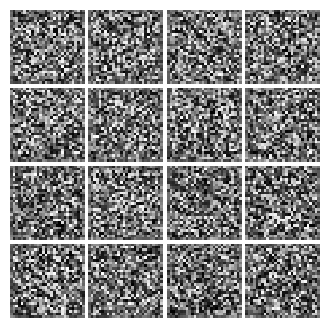


Iter: 250


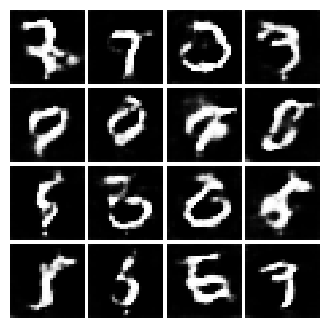


Iter: 500


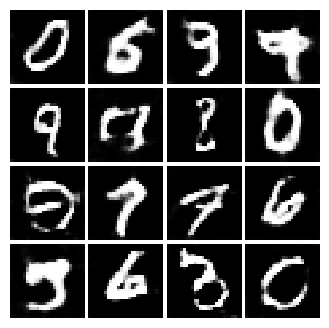


Iter: 750


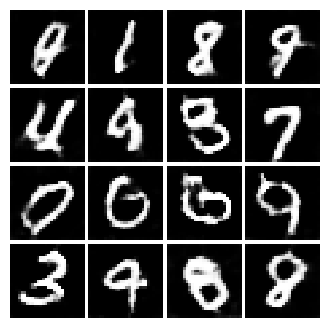


Iter: 1000


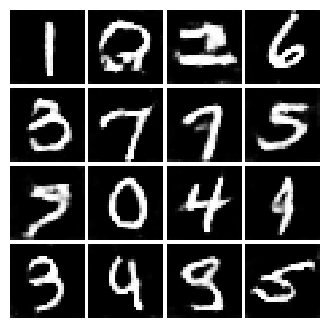


Iter: 1250


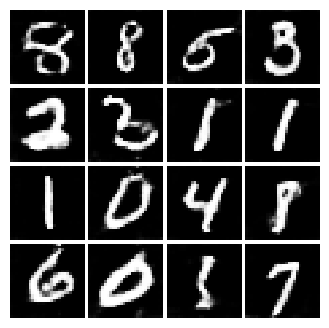


Iter: 1500


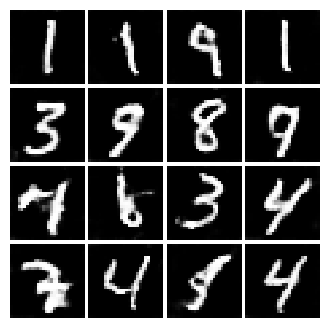


Iter: 1750


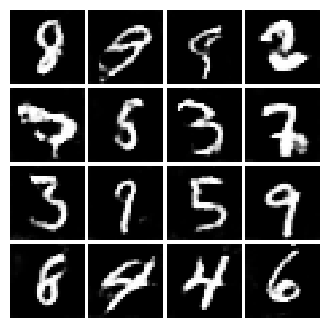


Iter: 2000


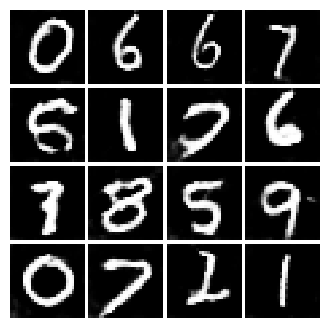


Iter: 2250


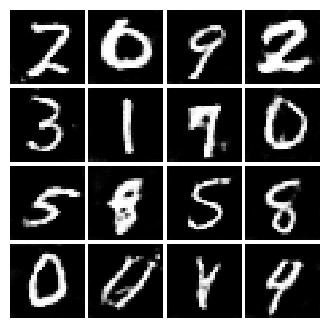

In [37]:
numIter = 0
for img in images:
    print(f'Iter: {numIter}')
    show_images(img)
    plt.show()
    numIter += 250
    print()

## Inline Question 3

What does your final DCGAN image look like?

DCGAN final image:


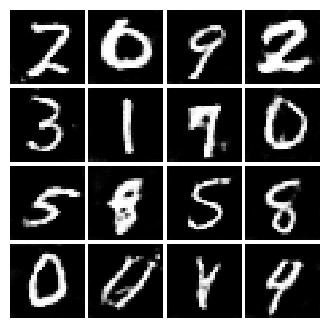

In [38]:
# This output is your answer.
print('DCGAN final image:')
show_images(images[-1])
plt.show()

## Inline Question 4 (1 point)
We will look at an example to see why alternating minimization of the same objective (like in a GAN) can be tricky business.

Consider $f(x,y)=xy$. What does $\min_x\max_y f(x,y)$ evaluate to? (0.4 points). Hint: minmax tries to minimize the maximum value achievable. Hint: Consider 3 separate cases: $x>0$, $x=0$, and $x<0$.

Now try to evaluate this function numerically for 6 steps, starting at the point $(1,1)$,
by using alternating gradient (first updating y, then updating x using that updated y) with step size $1$. **Here step size is the learning_rate, and steps will be learning_rate * gradient.**
You'll find that writing out the update step in terms of $x_t,y_t,x_{t+1},y_{t+1}$ will be useful.

Record the six pairs of explicit values for $(x_t,y_t)$ in the table below and briefly explain what $f(x,y)$ evaluates to (0.6 points).

i.e., for $\eta = 1$, calculate:

For $i = 1, 2, 3, ...$

1. $y_i = y_{i-1} + \eta \frac{\partial f(x, y)}{\partial y}\rvert_{x = x_{i-1}, y = y_{i-1}}$
2. $x_i = x_{i-1} - \eta \frac{\partial f(x, y)}{\partial x}\rvert_{x = x_{i-1}, y = y_{i}}$

### Your answer:

**Analytical answer:** For $f(x,y) = xy$:
- If $x > 0$: $\max_y xy = +\infty$ (let $y \to +\infty$)
- If $x < 0$: $\max_y xy = +\infty$ (let $y \to -\infty$)
- If $x = 0$: $\max_y xy = 0$

Therefore $\min_x \max_y f(x,y) = \boxed{0}$, achieved at $x = 0$.

**Numerical evaluation** with $\eta=1$, starting at $(x_0, y_0) = (1, 1)$:

Since $\frac{\partial f}{\partial y} = x$ and $\frac{\partial f}{\partial x} = y$, the updates are:
$$y_i = y_{i-1} + x_{i-1}, \qquad x_i = x_{i-1} - y_i$$

| $y_0$  | $y_1$  | $y_2$  | $y_3$  | $y_4$  | $y_5$  | $y_6$  |
| :----- | :----- | :----- | :----- | :----- | :----- | :----- |
|   1    |   2    |   1    |  -1    |  -2    |  -1    |   1    |
| $x_0$  | $x_1$  | $x_2$  | $x_3$  | $x_4$  | $x_5$  | $x_6$  |
|   1    |  -1    |  -2    |  -1    |   1    |   2    |   1    |

The iterates form a **period-6 cycle** and return exactly to $(1, 1)$ after 6 steps, never approaching the true optimum $(0, 0)$.

## Inline Question 5 (1 point)
Using this method, will we ever reach the optimal value? Why or why not?

### Your answer:

No, we will never reach the optimal value of $0$ at $(x^*, y^*) = (0, 0)$. The numerical example above shows that alternating gradient updates on $f(x,y) = xy$ produce a **periodic orbit** — the iterates cycle through the same 6 points indefinitely and never converge. This is because the saddle point $(0,0)$ is unstable under alternating gradient dynamics: the gradient of $f$ with respect to $x$ points away from the optimum whenever $y \neq 0$, and vice versa. Instead of spiraling inward, the updates orbit around the saddle point at a constant radius. This is a fundamental challenge in GAN training — the minimax objective has a saddle point structure, and naive alternating gradient descent/ascent can cycle rather than converge, which is why more sophisticated optimizers and training tricks are needed in practice.

## Inline Question 6 (1 point)
If the generator loss decreases during training while the discriminator loss stays at a constant high value from the start, is this a good sign? Why or why not? A qualitative answer is sufficient.

### Your answer:

No, this is **not** a good sign. A persistently high discriminator loss from the start means the discriminator is failing to distinguish real images from fake ones — it is essentially no better than random guessing. In that scenario, the generator loss decreasing simply means the generator has learned to exploit a weak, non-improving discriminator rather than genuinely learning to produce realistic images. Without a competent discriminator providing meaningful gradient signal, the generator receives no useful feedback about what makes an image look real. This often indicates **mode collapse** or a training imbalance where the generator dominates too early. Healthy GAN training should look like a dynamic equilibrium: both losses fluctuate as the two networks push back against each other, with neither completely overpowering the other.